# Matrix-Making Notebook

The purpose of this notebook is to create matrix-like figures that summarize accuracy of the model across various experiments run in climate_experiments.ipynb.

### Imports and File Stitching

In [2]:
# General Imports
import pandas as pd
import numpy as np
import os
import sys
import glob
import string


# Combinations
from itertools import combinations

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# ----File Stitching----
# If in climate_experiments folder, cd back to MamalakisResearch folder
if os.path.basename(os.getcwd()) == "climate_experiments":
   os.chdir('..')

### Read Files

In [3]:
# Read all csv files in climate_experiments folder
path = os.getcwd() + '/climate_experiments/'
csvs = glob.glob(os.path.join(path, "*.csv"))
summaries = []
for csv in csvs:
    df = pd.read_csv(csv)
    summaries.append(df)
summaries

[   scenario  early_yr  late_yr  mean_pred  accuracy  \
 0    ssp119      2015     2025   0.639999      0.78   
 1    ssp119      2015     2035   0.512207      0.56   
 2    ssp119      2015     2045   0.496769      1.00   
 3    ssp119      2015     2055   0.552726      0.98   
 4    ssp119      2015     2065   0.484289      0.96   
 5    ssp119      2015     2075   0.974333      0.48   
 6    ssp119      2015     2085   0.500245      1.00   
 7    ssp119      2025     2035   0.491750      0.70   
 8    ssp119      2025     2045   0.554211      0.66   
 9    ssp119      2025     2055   0.495809      0.76   
 10   ssp119      2025     2065   0.553294      0.54   
 11   ssp119      2025     2075   0.493363      0.98   
 12   ssp119      2025     2085   0.509532      0.98   
 13   ssp119      2035     2045   0.470797      0.46   
 14   ssp119      2035     2055   0.502710      0.74   
 15   ssp119      2035     2065   0.488995      0.76   
 16   ssp119      2035     2075   0.477202      

In [4]:
# checking all csvs loaded 
len(summaries)

10

In [5]:
# checking all cols in each csv loaded
for i in range(len(summaries)):
    print(summaries[i].columns)

Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
     

### Calculations

In [6]:
# Calculate mean and standard deviation of accuracy between runs of the same experiment
def get_mean_std(summaries, scenario):
    # Make a df to hold: 
    # a) metadata
        # making one col for scenario in a new dataframe
    acc_df = pd.DataFrame(columns=['scenario'])
        # copying the other cols and the content inside it 
            # assuming all csv files share same structure for early and late yrs and scenario (which they should)
    acc_df['scenario'] = summaries[0]['scenario']
    acc_df['early'] = summaries[0]['early_yr']
    acc_df['late'] = summaries[0]['late_yr']
    
    # b) accuracies
        # looping through each csv file
    for i in range(len(csvs)):
        # making accuracy col for each run (like acc_1, acc_2, etc) so all accuracies are in separate cols rather than one big col
        acc_df[f"acc_{i}"] = summaries[i]['accuracy']
    
    # c) mean and std
        # making list of all cols in the created df if it starts with acc_
    acc_cols = [col for col in acc_df.columns if col.startswith('acc_')]
    # calculating avg of accuracy horizontally (so across all rows, rather than going down one accuracy col)
    acc_df['mean'] = acc_df[acc_cols].mean(axis=1)
    # same thing for std
    acc_df['std'] = acc_df[acc_cols].std(axis=1)

    # Drop the accuracy columns
    mean_std = acc_df.drop(columns=acc_cols)
    # filtering so that only keeps rows that match the scenario user passes into func
    mean_std = mean_std[mean_std['scenario'] == scenario]
    
    return mean_std

In [7]:
mean_std_119 = get_mean_std(summaries, "ssp119")
mean_std_119

,scenario,early,late,mean,std
0,ssp119,2015,2025,0.848,0.062681
1,ssp119,2015,2035,0.864,0.119926
2,ssp119,2015,2045,0.948,0.034254
3,ssp119,2015,2055,0.944,0.064498
4,ssp119,2015,2065,0.892,0.170281
5,ssp119,2015,2075,0.866,0.162221
6,ssp119,2015,2085,0.852,0.208103
7,ssp119,2025,2035,0.598,0.108505
8,ssp119,2025,2045,0.662,0.125945
9,ssp119,2025,2055,0.734,0.148788


In [8]:
mean_std_126 = get_mean_std(summaries, "ssp126")
mean_std_126

,scenario,early,late,mean,std
28,ssp126,2015,2025,0.762,0.150392
29,ssp126,2015,2035,0.914,0.116638
30,ssp126,2015,2045,0.964,0.059479
31,ssp126,2015,2055,0.950,0.138323
32,ssp126,2015,2065,0.880,0.209762
33,ssp126,2015,2075,0.926,0.121856
34,ssp126,2015,2085,0.914,0.157776
35,ssp126,2025,2035,0.628,0.107579
36,ssp126,2025,2045,0.726,0.175132
37,ssp126,2025,2055,0.730,0.181414


### Making a Matrix

In [9]:
def plot_unbinned_matrix(df, scenario_id="ssp119"):
   
    # set union to find the unique years for early and late start years from the df -- this is just in case bc the early and late yrs should alr be unique
        # pipe operator (|) combines the two combos of the unique 
    all_years = sorted(list(set(df['early'].unique()) | set(df['late'].unique())))
    
    # making df for matrix -- seaborn heatmap requires the row indices and col headers to be the year values (like it looks like the heatmap)
    matrix_df = df.pivot_table(
        index='early', # rows are early start yrs 
        columns='late', # cols are the late start yrs 
        values='mean', 
        aggfunc='mean'# avgs the accuracy for multiple csvs 
    )
    
    # ensures that only cells with ALL unique yr combos are there and everything else is NA
    matrix_df = matrix_df.reindex(index=all_years, columns=all_years)
    
    # labeling 
        # makes the yr range for the plot labels 
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    matrix_df.index = labels
    matrix_df.columns = labels

    # PLOT
    plt.figure(figsize=(14, 11))

    mask = np.tril(np.ones_like(matrix_df, dtype=bool), k=0)

    # draw heatmap WITHOUT seaborn annotations -- we'll add text manually for full control
    ax = sns.heatmap(
        matrix_df, 
        mask=mask,
        cmap='BuGn', 
        annot=False,   # disabled -- we annotate manually below
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": 1.0, "label": "Accuracy (Mean)"},
        vmin=0.5, vmax=1.0
    )

    # increase colorbar label and tick font sizes
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label("Accuracy (Mean)", fontsize=14, fontweight='bold')

    from matplotlib.lines import Line2D

    # manually annotate each visible cell with full control over boldness
    for y in range(len(matrix_df.index)):
        for x in range(len(matrix_df.columns)):
            val = matrix_df.iloc[y, x]

            if not mask[y, x] and not pd.isna(val):
                val_rounded = round(val, 2)
                is_significant = val_rounded > 0.68

                # choose text color: white on dark green, black on light cells
                # use the colormap to decide -- darker cells get white text
                normalized = (val - 0.5) / (1.0 - 0.5)  # normalize to [0, 1]
                text_color = 'white' if normalized > 0.6 else 'black'

                ax.text(
                    x + 0.5, y + 0.5,
                    f"{val:.2f}",
                    ha='center', va='center',
                    fontsize=16,
                    fontweight='bold' if is_significant else 'normal',
                    color='black'
)

                # non-significant cells: thin red diagonal lines
                if not is_significant:
                    ax.add_line(Line2D([x + 0.05, x + 0.95], [y + 0.05, y + 0.95],
                                       transform=ax.transData, color='red', linewidth=0.8, alpha=0.7))
                    ax.add_line(Line2D([x + 0.95, x + 0.05], [y + 0.05, y + 0.95],
                                       transform=ax.transData, color='red', linewidth=0.8, alpha=0.7))

    # --- net-zero lines ---
    if "119" in scenario_id:
        net_zero_bucket = "2045-2054"   # 2050 falls inside this bucket
        net_zero_label = "Net Zero ~2050 (SSP1-1.9)"
    elif "126" in scenario_id:
        net_zero_bucket = "2075-2084"   # 2075 falls inside this bucket
        net_zero_label = "Net Zero ~2075 (SSP1-2.6)"
    else:
        net_zero_bucket = None

    if net_zero_bucket is not None:
        col_labels = list(matrix_df.columns)
        row_labels = list(matrix_df.index)

        if net_zero_bucket in col_labels:
            nz_col_idx = col_labels.index(net_zero_bucket)
            ax.axvline(x=nz_col_idx + 0.5, color='steelblue', linewidth=2.5,
                       linestyle='--', zorder=5)

        if net_zero_bucket in row_labels:
            nz_row_idx = row_labels.index(net_zero_bucket)
            ax.axhline(y=nz_row_idx + 0.5, color='steelblue', linewidth=2.5,
                       linestyle='--', zorder=5)

        ax.legend(
            handles=[Line2D([0], [0], color='steelblue', linewidth=2.5,
                            linestyle='--', label=net_zero_label)],
            loc='lower right', fontsize=11, framealpha=0.85, edgecolor='gray'
        )

    # axis formatting
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=45, ha='left', fontweight='bold', fontsize=12)
    plt.yticks(rotation=45, va='top', fontweight='bold', fontsize=12)
    
    plt.xlabel("Late 10-Year Period", fontsize=13, fontweight='bold', labelpad=20)
    plt.ylabel("Early 10-Year Period", fontsize=13, fontweight='bold', labelpad=20)
    plt.title(f"Accuracy Matrix (Averaged Across 10 Runs): {scenario_id.upper()}", fontsize=18, fontweight='bold', pad=40)
    
    plt.tight_layout()
    plt.show()

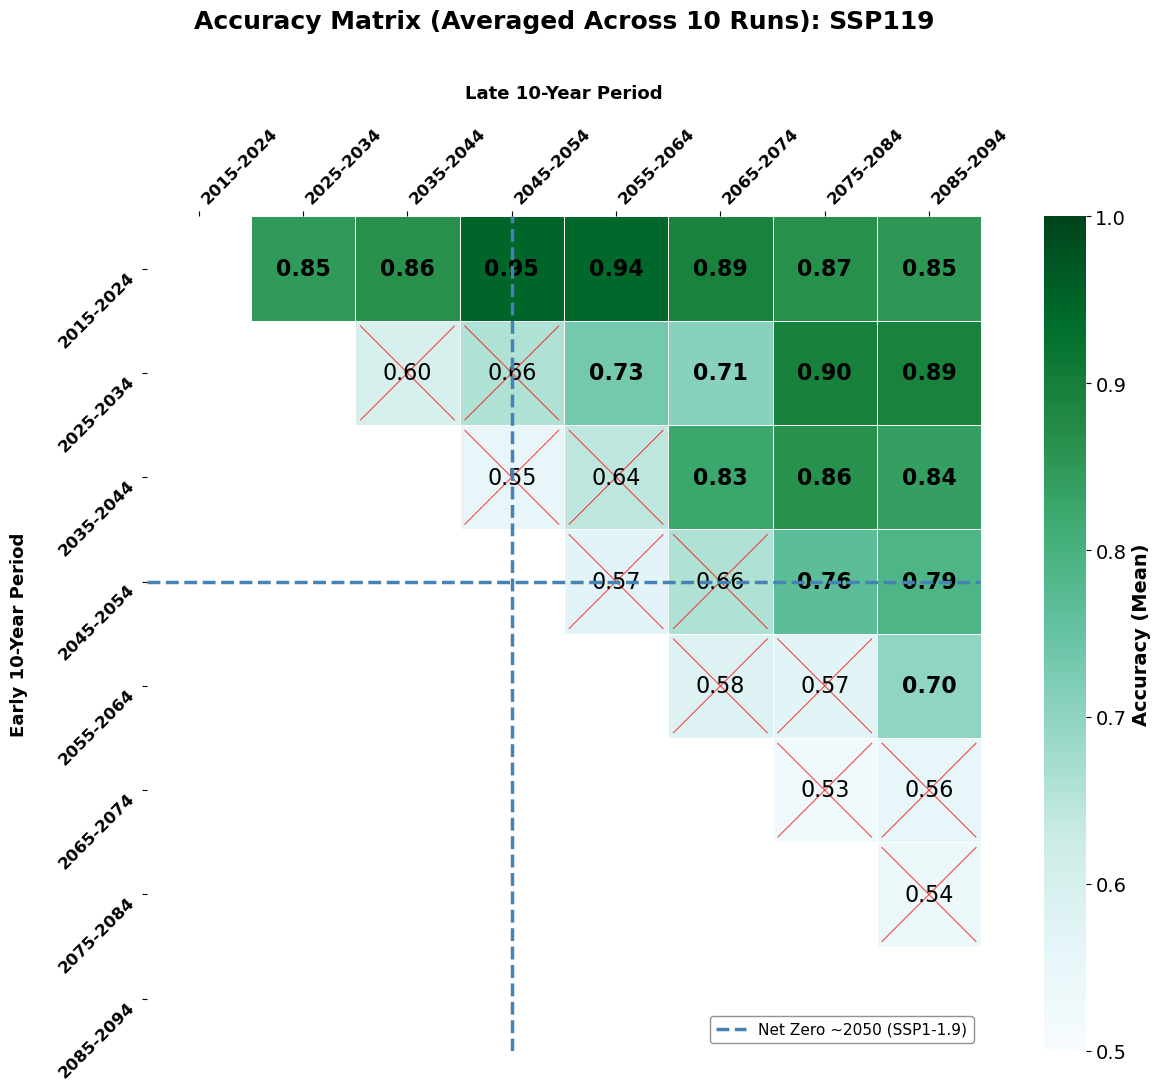

In [10]:
plot_unbinned_matrix(mean_std_119, scenario_id="ssp119")

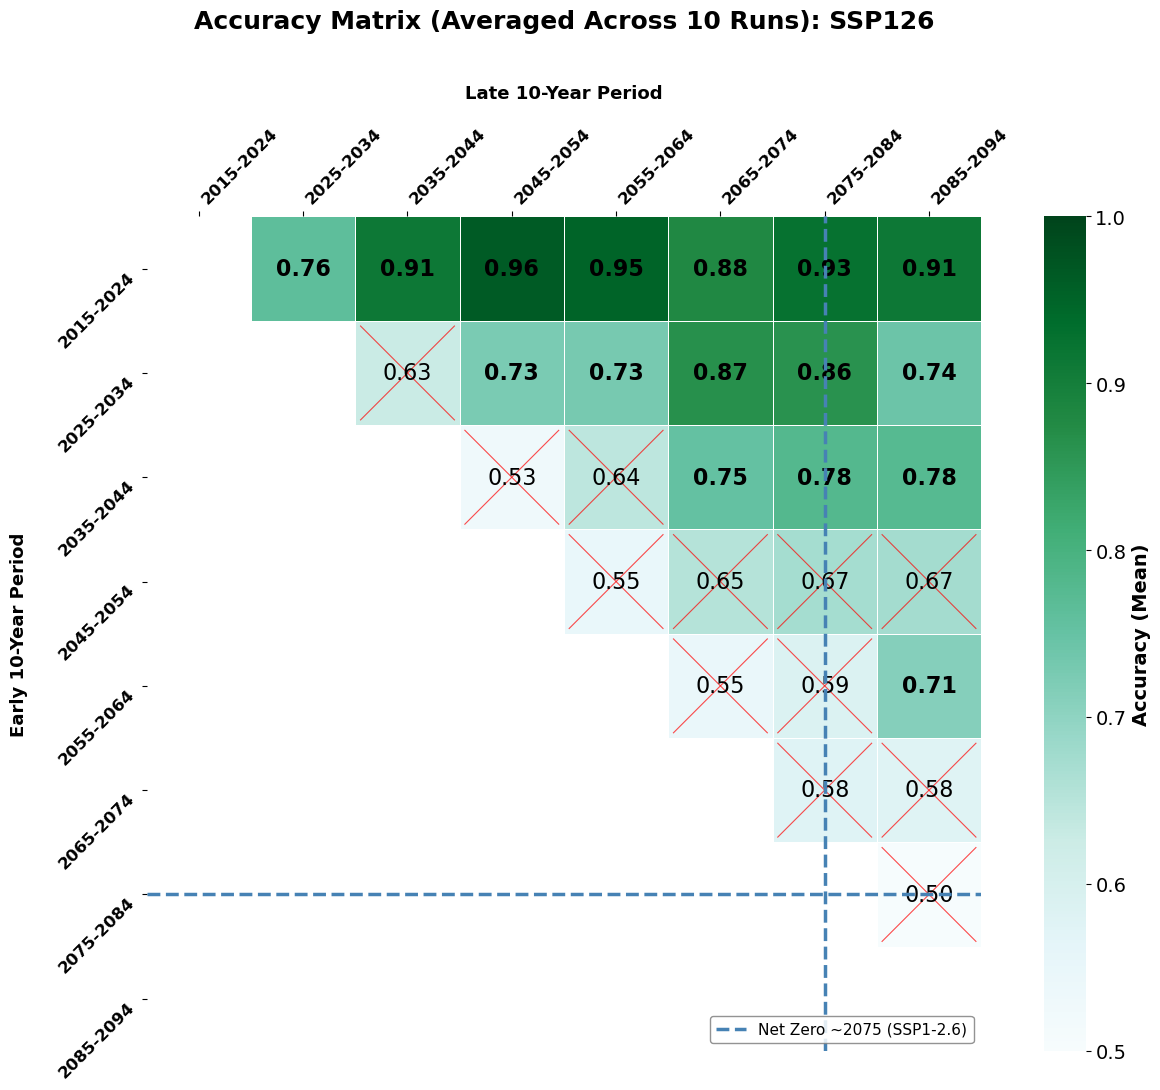

In [11]:
plot_unbinned_matrix(mean_std_126, scenario_id="ssp126")

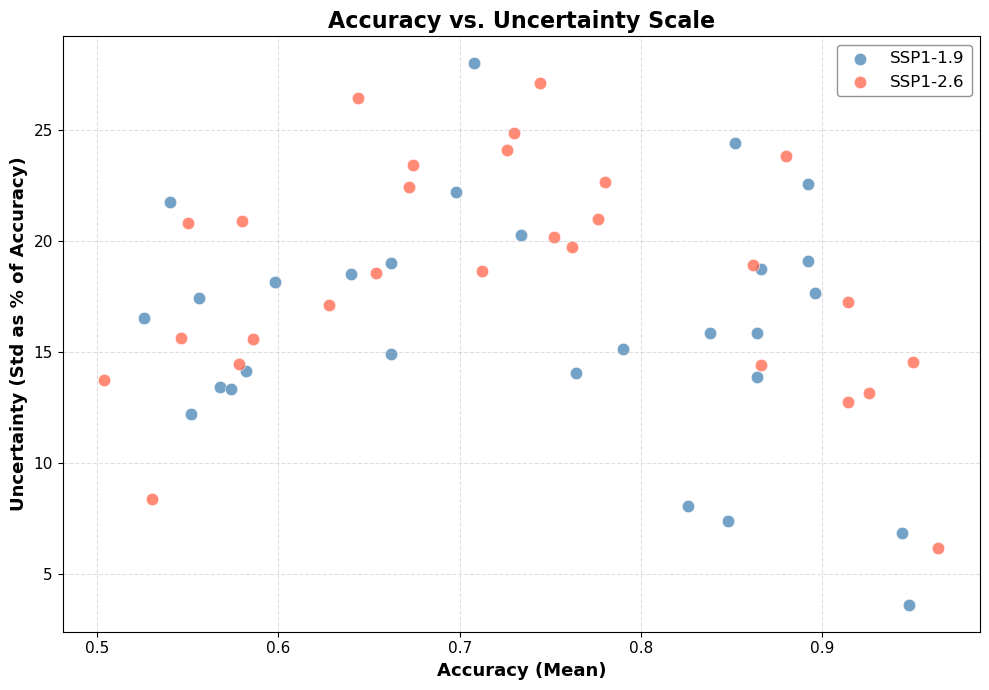

In [12]:
def plot_accuracy_vs_std(mean_std_119, mean_std_126):

    fig, ax = plt.subplots(figsize=(10, 7))

    # calculate std as a percentage of accuracy (deviation relative to accuracy level)
    df_119 = mean_std_119.dropna(subset=['mean', 'std']).copy()
    df_126 = mean_std_126.dropna(subset=['mean', 'std']).copy()

    df_119['std_pct'] = (df_119['std'] / df_119['mean']) * 100
    df_126['std_pct'] = (df_126['std'] / df_126['mean']) * 100

    # plot SSP1-1.9
    ax.scatter(
        df_119['mean'], df_119['std_pct'],
        color='steelblue', alpha=0.75, s=80, edgecolors='white', linewidths=0.5,
        label='SSP1-1.9'
    )

    # plot SSP1-2.6
    ax.scatter(
        df_126['mean'], df_126['std_pct'],
        color='tomato', alpha=0.75, s=80, edgecolors='white', linewidths=0.5,
        label='SSP1-2.6'
    )

    ax.set_xlabel("Accuracy (Mean)", fontsize=13, fontweight='bold')
    ax.set_ylabel("Uncertainty (Std as % of Accuracy)", fontsize=13, fontweight='bold')
    ax.set_title("Accuracy vs. Uncertainty Scale", fontsize=16, fontweight='bold')

    ax.legend(fontsize=12, framealpha=0.85, edgecolor='gray')
    ax.tick_params(labelsize=11)

    # light grid for readability
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_accuracy_vs_std(mean_std_119, mean_std_126)

In [13]:
def plot_std_matrix(df, scenario_id="ssp119"):
   
    # set union to find the unique years for early and late start years from the df -- this is just in case bc the early and late yrs should alr be unique
        # pipe operator (|) combines the two combos of the unique 
    all_years = sorted(list(set(df['early'].unique()) | set(df['late'].unique())))
    
    # making df for matrix -- seaborn heatmap requires the row indices and col headers to be the year values (like it looks like the heatmap)
    matrix_df = df.pivot_table(
        index='early', # rows are early start yrs 
        columns='late', # cols are the late start yrs 
        values='std', 
        aggfunc='mean'# avgs the standard deviation for multiple csvs 
    )
    
    # ensures that only cells with ALL unique yr combos are there and everything else is NA
    matrix_df = matrix_df.reindex(index=all_years, columns=all_years)
    
    # labeling 
        # makes the yr range for the plot labels 
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    matrix_df.index = labels
    matrix_df.columns = labels

    # PLOT
    plt.figure(figsize=(14, 11))
    

    # np.tril = create boolean lower triangle filter 
        # np.ones_like creates exact matrix size with true values
    # k=0 hides the diagonal cells by saying only the bottom half (starting where early == late) is true, therefore masking the lower half
    mask = np.tril(np.ones_like(matrix_df, dtype=bool), k=0)

    # seting plot features
    ax = sns.heatmap(
        matrix_df, 
        mask=mask, # masking the lower half 
        cmap='flare', 
        annot=True, # writing accuracy vals in cells
        fmt=".2f",      # rounded by 2 decimal points
        square=True, # every cell perfect square 
        linewidths=.5,
        # shrink colorbar size by 70% and specify label 
        cbar_kws={"shrink": .7, "label": "Standard Deviation (Mean)"},
        vmin=0, vmax=0.3 # 0.5 = random guessing
    )

    # making the shapes
    # looping through every cell with the nested for loops 
    for y in range(len(matrix_df.index)):
        for x in range(len(matrix_df.columns)):
            # this is the unique cell 
            val = matrix_df.iloc[y, x]
            
            
            # ensure data in val is not in the maask and not NA
            if not mask[y, x] and not pd.isna(val):

                # rounding values so that the symbols match whatever rounded values are in the heatmap cells
                val_rounded = round(val, 2)

             
    
                    
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=45, ha='left', fontweight='bold')
    plt.yticks(fontweight='bold')
    
    plt.xlabel("Late 10-Year Period", fontsize=12, fontweight='bold', labelpad=20)
    plt.ylabel("Early 10-Year Period", fontsize=12, fontweight='bold')
    plt.title(f"Standard Deviation Matrix: {scenario_id.upper()}", fontsize=18, fontweight='bold', pad=40)
    
    plt.tight_layout()
    plt.show()

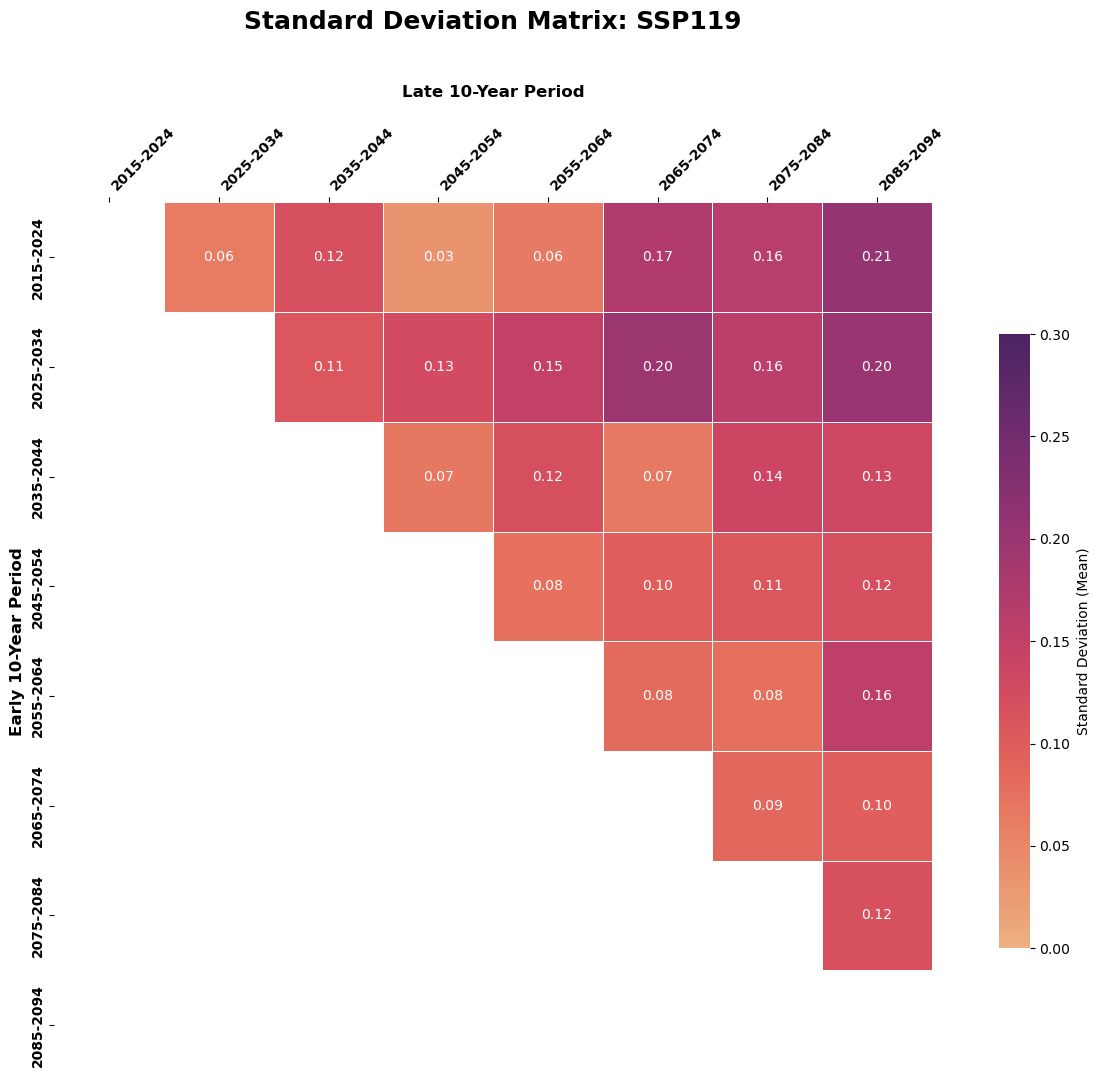

In [14]:
plot_std_matrix(mean_std_119)

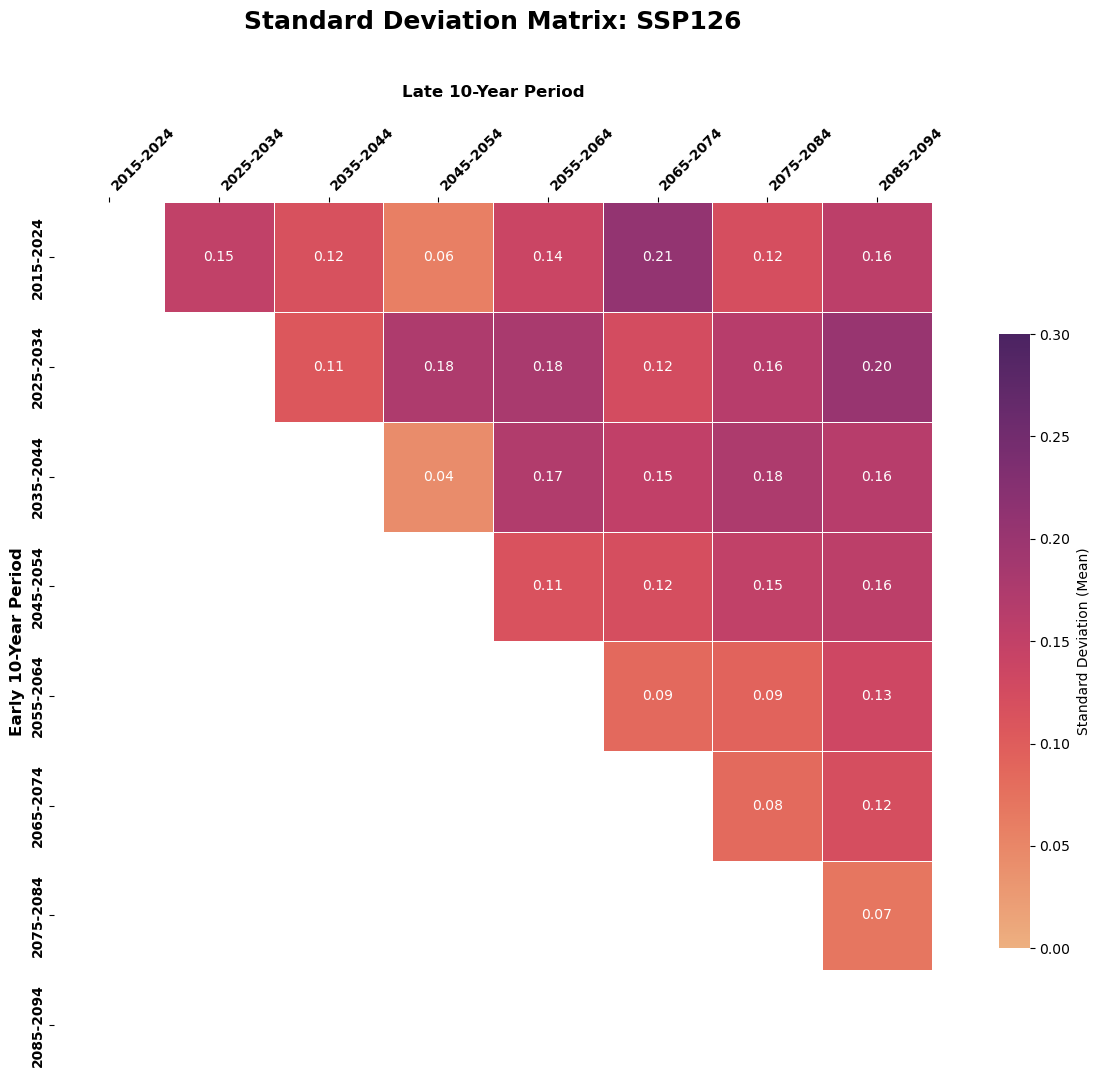

In [15]:
plot_std_matrix(mean_std_126, "ssp126")